# Apple Product Revenue Analysis (2017–2025): iPhone Dependence and Services Expansion

##  Project Overview

This project analyzes Apple’s product-level revenue performance from Fiscal Year 2017 through Fiscal Year 2025 using official SEC Form 10-K filings.

The objective is to examine how Apple’s ecosystem strategy has evolved over time and how revenue concentration, product mix shifts, and Services expansion have contributed to structural changes in Apple's revenue model

---

##  Key Questions

- How dependent is Apple on iPhone revenue?
- How has Services growth changed Apple’s revenue structure?
- When did Apple’s product mix structurally shift?
- Is Apple becoming less hardware-dependent over time?
- What does revenue composition tell us about long-term strategy?

---

##  Data Source

All financial data was manually collected from:

**Apple Inc. Form 10-K (Fiscal Years 2017–2025)**  
U.S. Securities and Exchange Commission (SEC) Filings

Revenue figures are reported in millions of USD and converted to billions for analysis and visualization clarity.

---

##  Methodology

- Data collected directly from SEC filings
- Revenue converted from millions to billions
- Year-over-year growth and product mix percentages calculated
- Time-series and composition visualizations constructed using Python (pandas + matplotlib)

---

This notebook focuses strictly on revenue composition and strategic implications, not stock price performance.

In [1]:
import pandas as pd


df = pd.read_csv("Apple_Product_Revenue_2017_2025.csv")


df = df[df["fiscal_year"].notna()]

df.head()

,fiscal_year,iphone_net_sales_usd,mac_net_sales_usd,ipad_net_sales_usd,wearables_home_accessories_net_sales_usd,services_net_sales_usd,total_net_sales_usd,source_filing
0,2017,139337,25569.0,18802.0,12826.0,32700.0,229234.0,Apple Inc. Form 10-K (Fiscal Year 2017)
1,2018,164888,25198.0,18380.0,17381.0,39748.0,265595.0,Apple Inc. Form 10-K (Fiscal Year 2018)
2,2019,142381,25740.0,21280.0,24482.0,46291.0,260174.0,Apple Inc. Form 10-K (Fiscal Year 2019)
3,2020,137781,28622.0,23724.0,30620.0,53768.0,274515.0,Apple Inc. Form 10-K (Fiscal Year 2020)
4,2021,191973,35190.0,31862.0,38367.0,68425.0,365817.0,Apple Inc. Form 10-K (Fiscal Year 2021)


In [2]:
df_analysis = df.copy()

df_analysis.head()

,fiscal_year,iphone_net_sales_usd,mac_net_sales_usd,ipad_net_sales_usd,wearables_home_accessories_net_sales_usd,services_net_sales_usd,total_net_sales_usd,source_filing
0,2017,139337,25569.0,18802.0,12826.0,32700.0,229234.0,Apple Inc. Form 10-K (Fiscal Year 2017)
1,2018,164888,25198.0,18380.0,17381.0,39748.0,265595.0,Apple Inc. Form 10-K (Fiscal Year 2018)
2,2019,142381,25740.0,21280.0,24482.0,46291.0,260174.0,Apple Inc. Form 10-K (Fiscal Year 2019)
3,2020,137781,28622.0,23724.0,30620.0,53768.0,274515.0,Apple Inc. Form 10-K (Fiscal Year 2020)
4,2021,191973,35190.0,31862.0,38367.0,68425.0,365817.0,Apple Inc. Form 10-K (Fiscal Year 2021)


In [3]:
pd.options.display.max_columns = None
pd.options.display.max_rows = None

In [4]:
display(df)

,fiscal_year,iphone_net_sales_usd,mac_net_sales_usd,ipad_net_sales_usd,wearables_home_accessories_net_sales_usd,services_net_sales_usd,total_net_sales_usd,source_filing
0,2017,139337,25569.0,18802.0,12826.0,32700.0,229234.0,Apple Inc. Form 10-K (Fiscal Year 2017)
1,2018,164888,25198.0,18380.0,17381.0,39748.0,265595.0,Apple Inc. Form 10-K (Fiscal Year 2018)
2,2019,142381,25740.0,21280.0,24482.0,46291.0,260174.0,Apple Inc. Form 10-K (Fiscal Year 2019)
3,2020,137781,28622.0,23724.0,30620.0,53768.0,274515.0,Apple Inc. Form 10-K (Fiscal Year 2020)
4,2021,191973,35190.0,31862.0,38367.0,68425.0,365817.0,Apple Inc. Form 10-K (Fiscal Year 2021)
5,2022,205489,40177.0,29292.0,41241.0,78129.0,394328.0,Apple Inc. Form 10-K (Fiscal Year 2022)
6,2023,200583,29357.0,28300.0,39845.0,85200.0,383285.0,Apple Inc. Form 10-K (Fiscal Year 2023)
7,2024,201183,29984.0,26694.0,37005.0,96169.0,391035.0,Apple Inc. Form 10-K (Fiscal Year 2024)
8,2025,209586,33708.0,28023.0,35686.0,109158.0,416161.0,Apple Inc. Form 10-K (Fiscal Year 2025)
9,source_url,SEC 10-K Filing,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   fiscal_year                               10 non-null     object 
 1   iphone_net_sales_usd                      10 non-null     object 
 2   mac_net_sales_usd                         9 non-null      float64
 3   ipad_net_sales_usd                        9 non-null      float64
 4   wearables_home_accessories_net_sales_usd  9 non-null      float64
 5   services_net_sales_usd                    9 non-null      float64
 6   total_net_sales_usd                       9 non-null      float64
 7   source_filing                             9 non-null      object 
dtypes: float64(5), object(3)
memory usage: 772.0+ bytes


In [6]:
df = df[pd.to_numeric(df["fiscal_year"], errors="coerce").notna()]

df["fiscal_year"] = df["fiscal_year"].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, 0 to 8
Data columns (total 8 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   fiscal_year                               9 non-null      int64  
 1   iphone_net_sales_usd                      9 non-null      object 
 2   mac_net_sales_usd                         9 non-null      float64
 3   ipad_net_sales_usd                        9 non-null      float64
 4   wearables_home_accessories_net_sales_usd  9 non-null      float64
 5   services_net_sales_usd                    9 non-null      float64
 6   total_net_sales_usd                       9 non-null      float64
 7   source_filing                             9 non-null      object 
dtypes: float64(5), int64(1), object(2)
memory usage: 648.0+ bytes


In [9]:
revenue_columns = [
    "iphone_net_sales_usd",
    "mac_net_sales_usd",
    "ipad_net_sales_usd",
    "wearables_home_accessories_net_sales_usd",
    "services_net_sales_usd",
    "total_net_sales_usd"
]

# Convert all revenue columns to numeric
for col in revenue_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, 0 to 8
Data columns (total 8 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   fiscal_year                               9 non-null      int64  
 1   iphone_net_sales_usd                      9 non-null      int64  
 2   mac_net_sales_usd                         9 non-null      float64
 3   ipad_net_sales_usd                        9 non-null      float64
 4   wearables_home_accessories_net_sales_usd  9 non-null      float64
 5   services_net_sales_usd                    9 non-null      float64
 6   total_net_sales_usd                       9 non-null      float64
 7   source_filing                             9 non-null      object 
dtypes: float64(5), int64(2), object(1)
memory usage: 648.0+ bytes


In [10]:
df_analysis = df.copy()

df_analysis[revenue_columns] = df_analysis[revenue_columns] / 1000
df_analysis[revenue_columns] = df_analysis[revenue_columns].round(1)

df_analysis.head()

,fiscal_year,iphone_net_sales_usd,mac_net_sales_usd,ipad_net_sales_usd,wearables_home_accessories_net_sales_usd,services_net_sales_usd,total_net_sales_usd,source_filing
0,2017,139.3,25.6,18.8,12.8,32.7,229.2,Apple Inc. Form 10-K (Fiscal Year 2017)
1,2018,164.9,25.2,18.4,17.4,39.7,265.6,Apple Inc. Form 10-K (Fiscal Year 2018)
2,2019,142.4,25.7,21.3,24.5,46.3,260.2,Apple Inc. Form 10-K (Fiscal Year 2019)
3,2020,137.8,28.6,23.7,30.6,53.8,274.5,Apple Inc. Form 10-K (Fiscal Year 2020)
4,2021,192.0,35.2,31.9,38.4,68.4,365.8,Apple Inc. Form 10-K (Fiscal Year 2021)


In [11]:
df.tail()

,fiscal_year,iphone_net_sales_usd,mac_net_sales_usd,ipad_net_sales_usd,wearables_home_accessories_net_sales_usd,services_net_sales_usd,total_net_sales_usd,source_filing
4,2021,191973,35190.0,31862.0,38367.0,68425.0,365817.0,Apple Inc. Form 10-K (Fiscal Year 2021)
5,2022,205489,40177.0,29292.0,41241.0,78129.0,394328.0,Apple Inc. Form 10-K (Fiscal Year 2022)
6,2023,200583,29357.0,28300.0,39845.0,85200.0,383285.0,Apple Inc. Form 10-K (Fiscal Year 2023)
7,2024,201183,29984.0,26694.0,37005.0,96169.0,391035.0,Apple Inc. Form 10-K (Fiscal Year 2024)
8,2025,209586,33708.0,28023.0,35686.0,109158.0,416161.0,Apple Inc. Form 10-K (Fiscal Year 2025)


## Total Revenue Growth (2017–2025)

This visualization shows Apple's total net sales growth over time, highlighting overall revenue expansion and structural inflection points in the business.

Revenue is displayed in billions of USD.

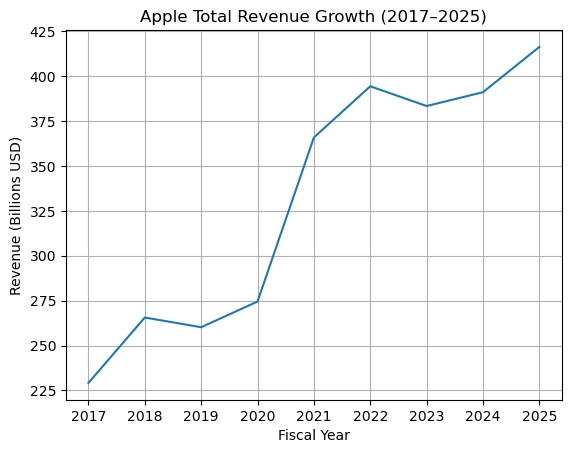

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Reload fresh
df = pd.read_csv("Apple_Product_Revenue_2017_2025.csv")

# Remove non-numeric fiscal_year rows (kills source_url row)
df = df[pd.to_numeric(df["fiscal_year"], errors="coerce").notna()]
df["fiscal_year"] = df["fiscal_year"].astype(int)

# Columns to convert
revenue_columns = [
    "iphone_net_sales_usd",
    "mac_net_sales_usd",
    "ipad_net_sales_usd",
    "wearables_home_accessories_net_sales_usd",
    "services_net_sales_usd",
    "total_net_sales_usd"
]

# Convert to numeric
for col in revenue_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert to billions
df[revenue_columns] = (df[revenue_columns] / 1000).round(1)

# Sort just to be safe
df = df.sort_values("fiscal_year")

# Plot
plt.figure()
plt.plot(df["fiscal_year"], df["total_net_sales_usd"])
plt.title("Apple Total Revenue Growth (2017–2025)")
plt.xlabel("Fiscal Year")
plt.ylabel("Revenue (Billions USD)")
plt.xticks(df["fiscal_year"])
plt.grid(True)
plt.show()

## Revenue by Product Category (Stacked)

This stacked area chart illustrates how Apple's revenue composition has evolved across product categories from 2017 to 2025.

The visualization highlights the structural growth of Services and the relative dominance of iPhone within the ecosystem.

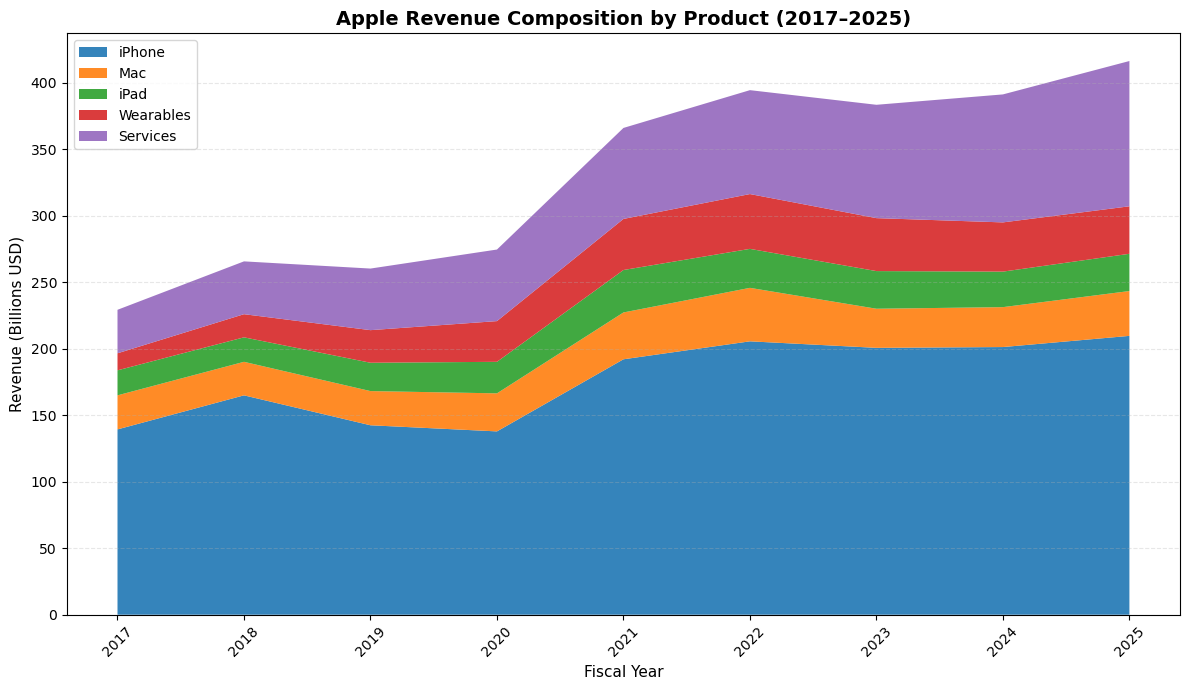

In [22]:
plt.figure(figsize=(12, 7))

plt.stackplot(
    df["fiscal_year"],
    df["iphone_net_sales_usd"],
    df["mac_net_sales_usd"],
    df["ipad_net_sales_usd"],
    df["wearables_home_accessories_net_sales_usd"],
    df["services_net_sales_usd"],
    alpha=0.9
)

plt.title("Apple Revenue Composition by Product (2017–2025)", fontsize=14, weight='bold')
plt.xlabel("Fiscal Year", fontsize=11)
plt.ylabel("Revenue (Billions USD)", fontsize=11)
plt.xticks(df["fiscal_year"], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.legend(
    ["iPhone", "Mac", "iPad", "Wearables", "Services"],
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [29]:
for col in ["iPhone", "Mac", "iPad", "Wearables", "Services", "Total"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["iPhone_%_of_Total"] = (df["iPhone"] / df["Total"]) * 100
df[["fiscal_year", "iPhone_%_of_Total"]]

,fiscal_year,iPhone_%_of_Total
0,2017,60.776614
1,2018,62.085843
2,2019,54.727133
3,2020,50.200364
4,2021,52.487698
5,2022,52.117677
6,2023,52.334986
7,2024,51.457801
8,2025,50.360404


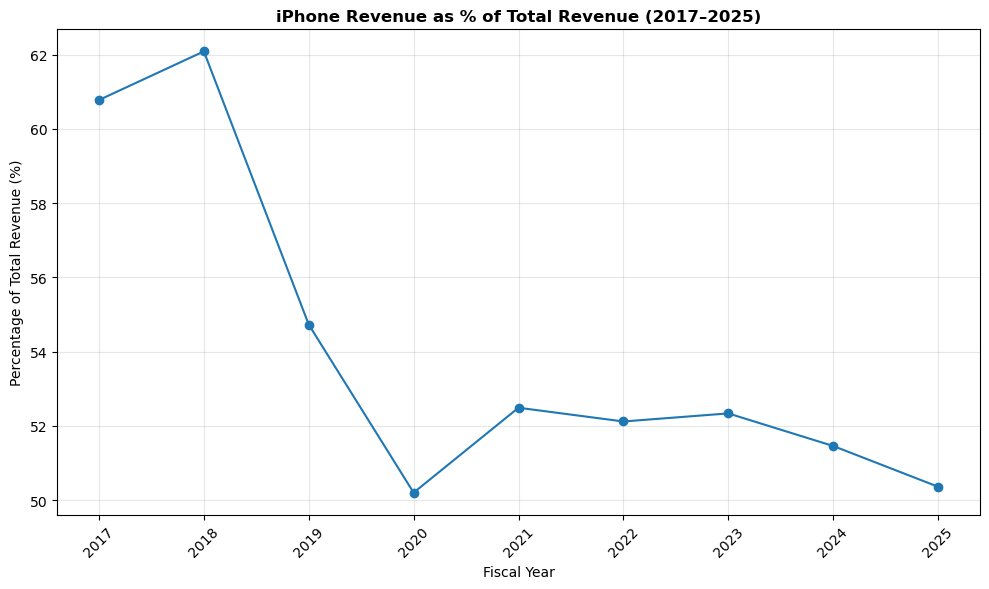

In [30]:
plt.figure(figsize=(10,6))

plt.plot(
    df["fiscal_year"],
    df["iPhone_%_of_Total"],
    marker='o'
)

plt.title("iPhone Revenue as % of Total Revenue (2017–2025)", weight='bold')
plt.xlabel("Fiscal Year")
plt.ylabel("Percentage of Total Revenue (%)")

plt.grid(alpha=0.3)
plt.xticks(df["fiscal_year"], rotation=45)

plt.tight_layout()
plt.show()

### COVID Impact and Structural Shift

While iPhone revenue declined during the initial COVID period (2020), 
the revenue slowdown had already begun in 2019, indicating market 
maturity rather than purely pandemic-driven weakness.

The significant rebound in 2021 was driven by pent-up demand and the 5G cycle.

More importantly, iPhone’s share of total revenue declined from over 60% 
in 2018 to approximately 50% by 2025, reflecting Apple’s strategic 
transition toward Services and ecosystem monetization.

In [31]:
df = df[df["fiscal_year"].astype(str).str.isnumeric()]

df["fiscal_year"] = df["fiscal_year"].astype(int)

df.tail()

,fiscal_year,iPhone,Mac,iPad,Wearables,Services,Total,source_filing,iPhone_%_of_Total
4,2021,192.0,35.2,31.9,38.4,68.4,365.8,Apple Inc. Form 10-K (Fiscal Year 2021),52.487698
5,2022,205.5,40.2,29.3,41.2,78.1,394.3,Apple Inc. Form 10-K (Fiscal Year 2022),52.117677
6,2023,200.6,29.4,28.3,39.8,85.2,383.3,Apple Inc. Form 10-K (Fiscal Year 2023),52.334986
7,2024,201.2,30.0,26.7,37.0,96.2,391.0,Apple Inc. Form 10-K (Fiscal Year 2024),51.457801
8,2025,209.6,33.7,28.0,35.7,109.2,416.2,Apple Inc. Form 10-K (Fiscal Year 2025),50.360404


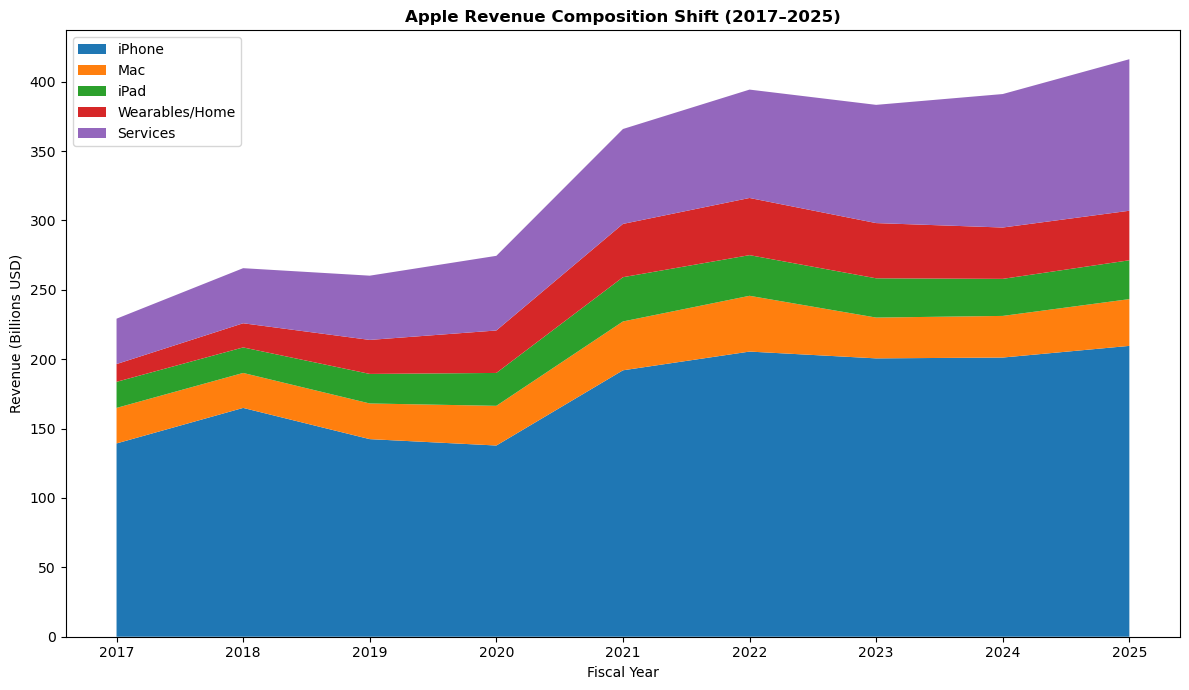

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))
plt.stackplot(
    df["fiscal_year"],
    df["iPhone"],
    df["Mac"],
    df["iPad"],
    df["Wearables"],
    df["Services"],
    labels=["iPhone", "Mac", "iPad", "Wearables/Home", "Services"]
)

plt.title("Apple Revenue Composition Shift (2017–2025)", weight="bold")
plt.xlabel("Fiscal Year")
plt.ylabel("Revenue (Billions USD)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [37]:
# Create percentage columns for each product category

df["iPhone_%"] = df["iPhone"] / df["Total"] * 100
df["Mac_%"] = df["Mac"] / df["Total"] * 100
df["iPad_%"] = df["iPad"] / df["Total"] * 100
df["Wearables_%"] = df["Wearables"] / df["Total"] * 100
df["Services_%"] = df["Services"] / df["Total"] * 100

df.head()

,fiscal_year,iPhone,Mac,iPad,Wearables,Services,Total,source_filing,iPhone_%_of_Total,iPhone_%,Mac_%,iPad_%,Wearables_%,Services_%
0,2017,139.3,25.6,18.8,12.8,32.7,229.2,Apple Inc. Form 10-K (Fiscal Year 2017),60.776614,60.776614,11.169284,8.202443,5.584642,14.267016
1,2018,164.9,25.2,18.4,17.4,39.7,265.6,Apple Inc. Form 10-K (Fiscal Year 2018),62.085843,62.085843,9.487952,6.927711,6.551205,14.947289
2,2019,142.4,25.7,21.3,24.5,46.3,260.2,Apple Inc. Form 10-K (Fiscal Year 2019),54.727133,54.727133,9.877018,8.186011,9.415834,17.794005
3,2020,137.8,28.6,23.7,30.6,53.8,274.5,Apple Inc. Form 10-K (Fiscal Year 2020),50.200364,50.200364,10.418944,8.633880,11.147541,19.599271
4,2021,192.0,35.2,31.9,38.4,68.4,365.8,Apple Inc. Form 10-K (Fiscal Year 2021),52.487698,52.487698,9.622745,8.720612,10.497540,18.698742


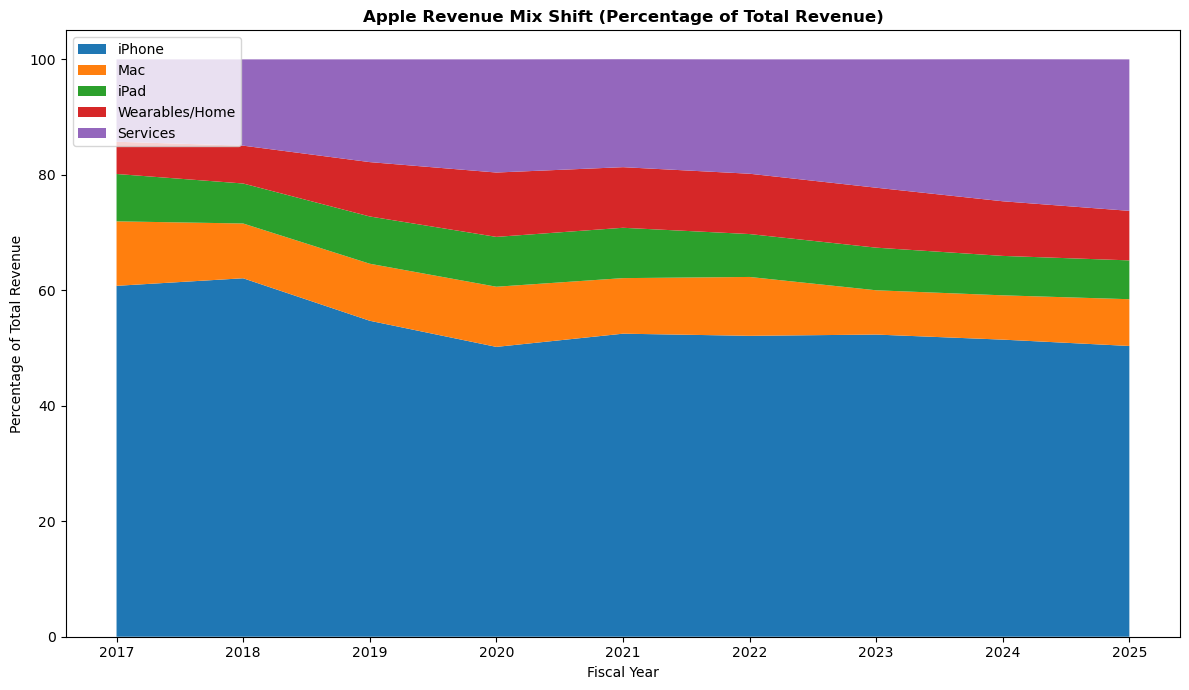

In [38]:
plt.figure(figsize=(12,7))

plt.stackplot(
    df["fiscal_year"],
    df["iPhone_%"],
    df["Mac_%"],
    df["iPad_%"],
    df["Wearables_%"],
    df["Services_%"],
    labels=["iPhone", "Mac", "iPad", "Wearables/Home", "Services"]
)

plt.title("Apple Revenue Mix Shift (Percentage of Total Revenue)", weight="bold")
plt.xlabel("Fiscal Year")
plt.ylabel("Percentage of Total Revenue")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [39]:
# Calculate iPhone Year-over-Year Growth %

df["iPhone_YoY_%"] = df["iPhone"].pct_change() * 100

df[["fiscal_year", "iPhone", "iPhone_YoY_%"]]

,fiscal_year,iPhone,iPhone_YoY_%
0,2017,139.3,NaN
1,2018,164.9,18.377602
2,2019,142.4,-13.644633
3,2020,137.8,-3.230337
4,2021,192.0,39.332366
5,2022,205.5,7.031250
6,2023,200.6,-2.384428
7,2024,201.2,0.299103
8,2025,209.6,4.174950


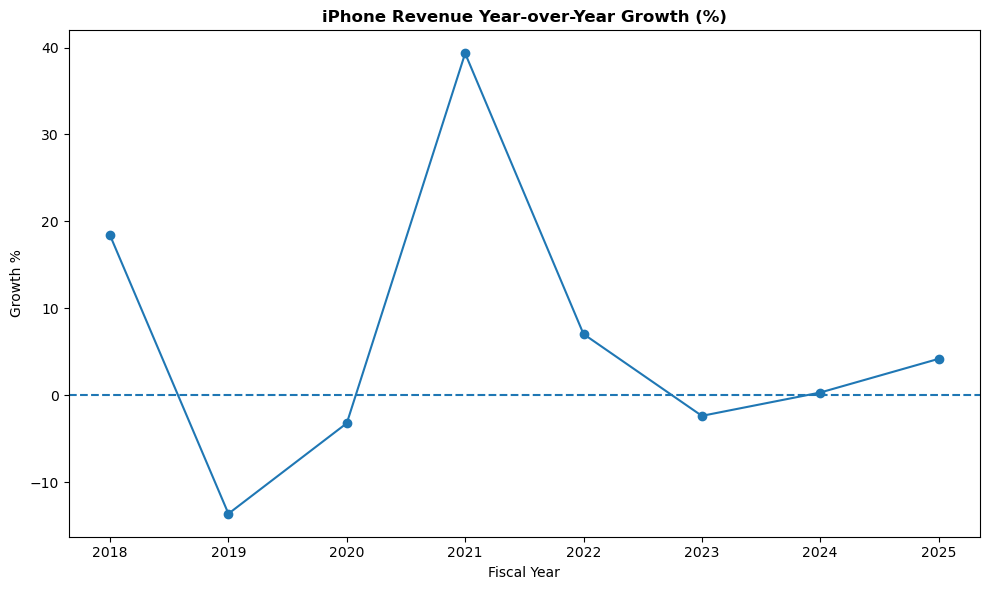

In [40]:
plt.figure(figsize=(10,6))

plt.plot(df["fiscal_year"], df["iPhone_YoY_%"], marker="o")

plt.axhline(0, linestyle="--")

plt.title("iPhone Revenue Year-over-Year Growth (%)", weight="bold")
plt.xlabel("Fiscal Year")
plt.ylabel("Growth %")

plt.tight_layout()
plt.show()

## iPhone Growth Acceleration and Normalization

iPhone revenue growth peaked sharply in Fiscal Year 2021, reflecting pandemic-driven demand acceleration and a major upgrade cycle.

However, growth normalized in subsequent years, indicating that the 2021 spike represented a temporary demand pull-forward rather than a permanent structural increase in growth rate.

This pattern suggests Apple’s long-term strategy is not reliant on sustained iPhone hypergrowth. Instead, Apple appears to be diversifying into Services and adjacent product categories to stabilize revenue and reduce volatility over time.

## Services Growth vs. iPhone Normalization

While iPhone revenue experienced a sharp acceleration in Fiscal Year 2021 followed by normalization, Services revenue demonstrates a structurally different growth pattern.

Unlike iPhone revenue — which is cyclical and heavily influenced by upgrade cycles — Services revenue has shown consistent expansion across multiple fiscal years.

This divergence is strategically important:

- **iPhone** represents hardware-driven demand cycles.
- **Services** represents recurring, ecosystem-driven monetization.
- Stable Services growth reduces long-term revenue volatility.

If Services continues expanding while iPhone growth stabilizes, Apple becomes structurally less dependent on hardware supercycles and increasingly anchored in recurring revenue streams.

In [41]:
# Calculate Services Year-over-Year Growth %

df["Services_YoY_%"] = df["Services"].pct_change() * 100

df[["fiscal_year", "Services", "Services_YoY_%"]]

,fiscal_year,Services,Services_YoY_%
0,2017,32.7,NaN
1,2018,39.7,21.406728
2,2019,46.3,16.624685
3,2020,53.8,16.198704
4,2021,68.4,27.137546
5,2022,78.1,14.181287
6,2023,85.2,9.090909
7,2024,96.2,12.910798
8,2025,109.2,13.513514


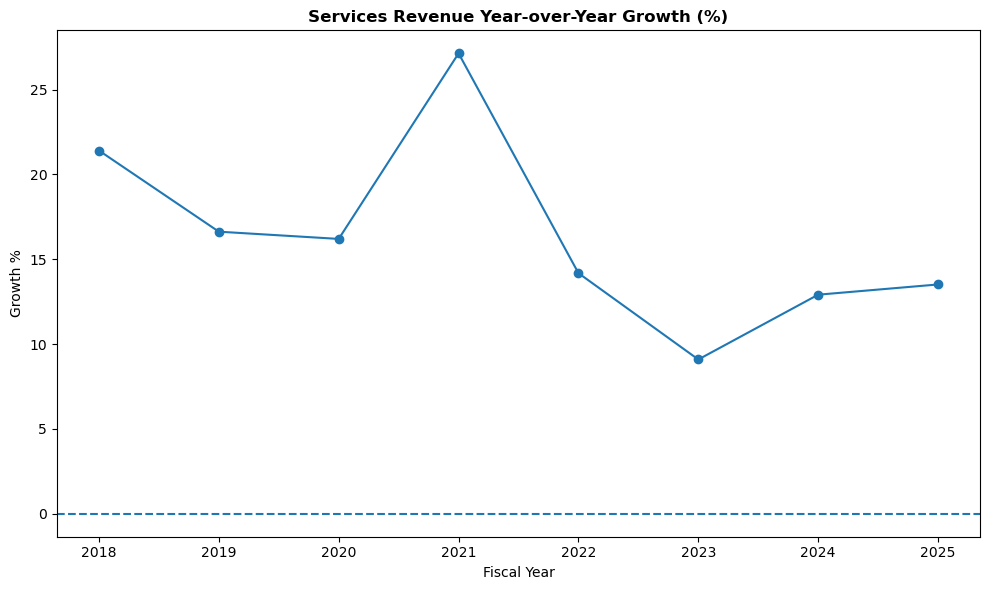

In [42]:
plt.figure(figsize=(10,6))

plt.plot(df["fiscal_year"], df["Services_YoY_%"], marker="o")

plt.axhline(0, linestyle="--")

plt.title("Services Revenue Year-over-Year Growth (%)", weight="bold")
plt.xlabel("Fiscal Year")
plt.ylabel("Growth %")

plt.tight_layout()
plt.show()

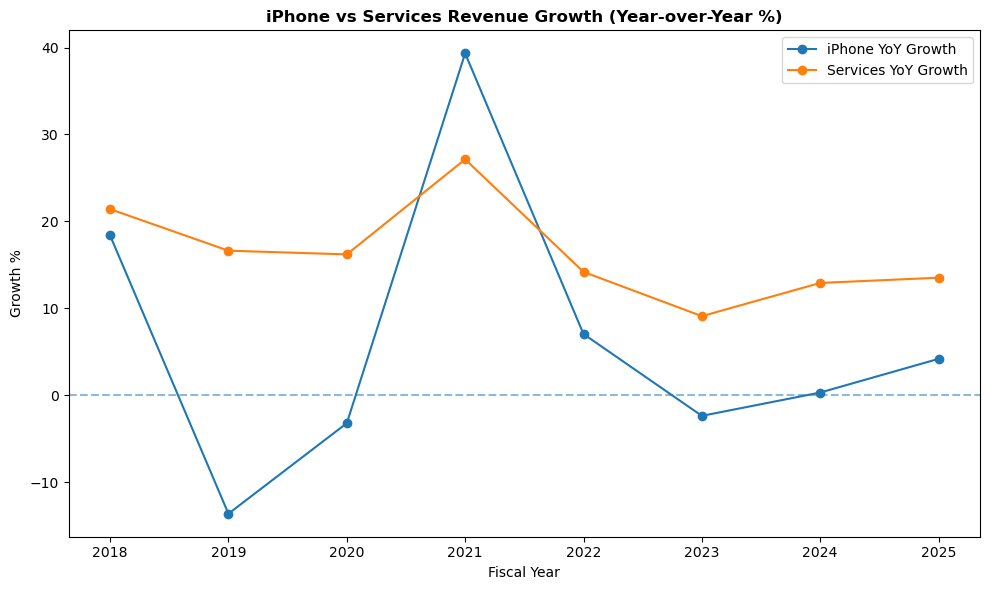

In [46]:
plt.figure(figsize=(10,6))

plt.plot(df["fiscal_year"], df["iPhone_YoY_%"], marker="o", label="iPhone YoY Growth")
plt.plot(df["fiscal_year"], df["Services_YoY_%"], marker="o", label="Services YoY Growth")

plt.axhline(0, linestyle="--", alpha=0.5)

plt.title("iPhone vs Services Revenue Growth (Year-over-Year %)", weight="bold")
plt.xlabel("Fiscal Year")
plt.ylabel("Growth %")

plt.legend()
plt.tight_layout()
plt.show()

## iPhone vs Services: Volatility vs Stability

A direct comparison of year-over-year growth highlights a key strategic shift in Apple’s business model.

- **iPhone growth is volatile**, reflecting hardware upgrade cycles and macroeconomic shocks.
- **Services growth is more stable**, remaining positive across the period and compounding from a larger base after 2021.

Even though both categories accelerated during Fiscal Year 2021, Services maintained consistent expansion afterward, reinforcing the role of Apple’s ecosystem in generating recurring revenue and reducing long-term dependence on hardware supercycles.

## Strategic Divergence: Hardware Cyclicality vs Platform Stability

The post-2021 divergence between iPhone and Services growth illustrates a structural shift in Apple’s revenue profile.

While iPhone revenue growth demonstrates cyclical volatility driven by upgrade cycles and macroeconomic conditions, Services revenue exhibits consistent positive expansion.

Even after the pandemic-driven acceleration in 2021, Services growth normalized without contraction, indicating structural resilience.

This divergence suggests Apple’s long-term strategy is successfully reducing dependency on hardware supercycles and increasing the contribution of recurring, ecosystem-driven revenue streams.

In [48]:
df["Services_%_of_Total"] = (df["Services"] / df["Total"]) * 100

df[["fiscal_year", "Services_%_of_Total"]]

,fiscal_year,Services_%_of_Total
0,2017,14.267016
1,2018,14.947289
2,2019,17.794005
3,2020,19.599271
4,2021,18.698742
5,2022,19.807253
6,2023,22.228020
7,2024,24.603581
8,2025,26.237386


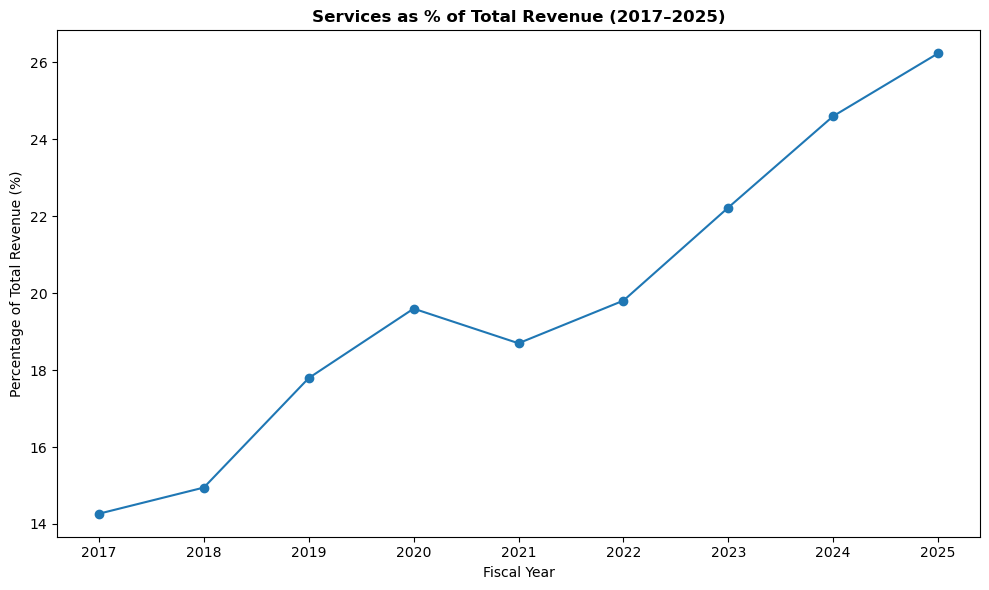

In [49]:
plt.figure(figsize=(10,6))

plt.plot(df["fiscal_year"], df["Services_%_of_Total"], marker="o")

plt.title("Services as % of Total Revenue (2017–2025)", weight="bold")
plt.xlabel("Fiscal Year")
plt.ylabel("Percentage of Total Revenue (%)")

plt.tight_layout()
plt.show()

## Structural Shift: Services Expansion Within Revenue Mix

Services revenue has increased from approximately 14% of total revenue in 2017 to over 25% by 2025.

Unlike temporary hardware-driven growth spikes, this upward trend reflects a structural rebalancing of Apple’s revenue composition.

The expanding contribution of Services suggests increasing monetization of Apple’s installed base, supporting a transition toward recurring, platform-driven revenue streams.

This structural shift reduces revenue volatility and enhances long-term strategic resilience.

In [51]:
# Create Hardware aggregate (everything except Services)
df["Hardware"] = df["iPhone"] + df["Mac"] + df["iPad"] + df["Wearables"]

# Calculate percentage split (using Total)
df["Hardware_%"] = (df["Hardware"] / df["Total"]) * 100
df["Services_%"] = (df["Services"] / df["Total"]) * 100

df[["fiscal_year", "Hardware_%", "Services_%"]]

,fiscal_year,Hardware_%,Services_%
0,2017,85.732984,14.267016
1,2018,85.052711,14.947289
2,2019,82.205995,17.794005
3,2020,80.400729,19.599271
4,2021,81.328595,18.698742
5,2022,80.192747,19.807253
6,2023,77.771980,22.228020
7,2024,75.421995,24.603581
8,2025,73.762614,26.237386


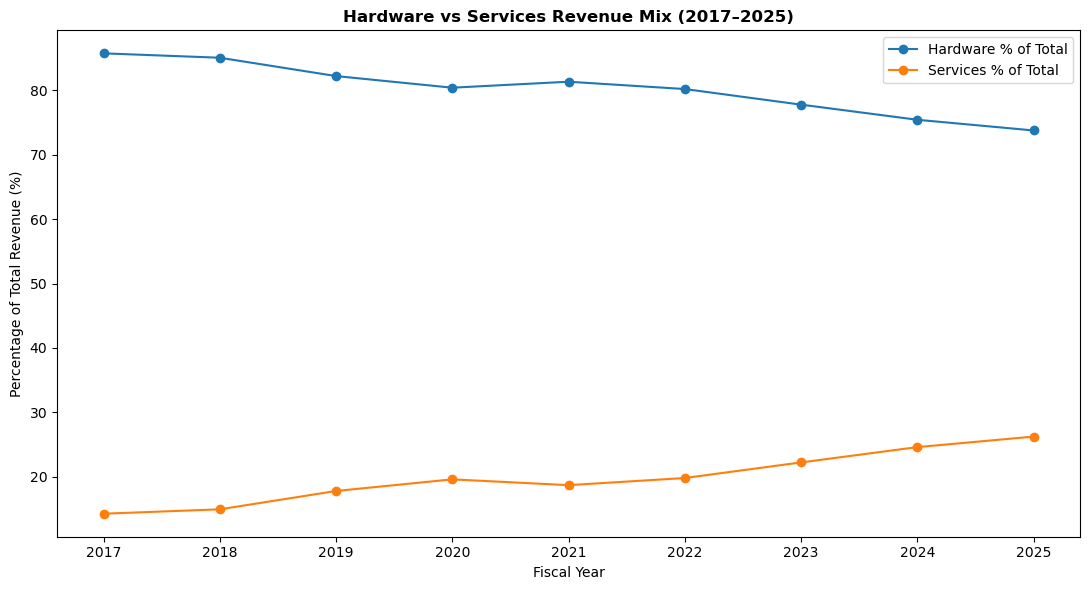

In [52]:
plt.figure(figsize=(11,6))

plt.plot(df["fiscal_year"], df["Hardware_%"], marker="o", label="Hardware % of Total")
plt.plot(df["fiscal_year"], df["Services_%"], marker="o", label="Services % of Total")

plt.title("Hardware vs Services Revenue Mix (2017–2025)", weight="bold")
plt.xlabel("Fiscal Year")
plt.ylabel("Percentage of Total Revenue (%)")

plt.legend()
plt.tight_layout()
plt.show()

## Revenue Mix Transformation: From Hardware Dominance to Ecosystem Monetization

Between 2017 and 2025, Apple’s revenue composition demonstrates a measurable shift.

Hardware revenue declined from approximately 85% of total revenue to nearly 74%, while Services expanded from roughly 14% to over 26%.

This trend reflects a gradual but consistent transition toward recurring, ecosystem-driven monetization.

Rather than replacing hardware revenue, Services growth complements and stabilizes the business model, reducing exposure to hardware supercycles and increasing long-term revenue resilience.

In [54]:
df = df.sort_values("fiscal_year")

years = df["fiscal_year"].iloc[-1] - df["fiscal_year"].iloc[0]

hardware_start = df["Hardware"].iloc[0]
hardware_end = df["Hardware"].iloc[-1]

services_start = df["Services"].iloc[0]
services_end = df["Services"].iloc[-1]

hardware_cagr = ((hardware_end / hardware_start) ** (1 / years)) - 1
services_cagr = ((services_end / services_start) ** (1 / years)) - 1

print(f"Hardware CAGR: {hardware_cagr * 100:.2f}%")
print(f"Services CAGR: {services_cagr * 100:.2f}%")

Hardware CAGR: 5.74%
Services CAGR: 16.27%


## Long-Term Compounding Differential (2017–2025)

Between 2017 and 2025, Hardware revenue compounded at approximately 5.7% annually, while Services revenue compounded at over 16%.

This 3x growth differential highlights a structural shift in Apple’s business model.

While Hardware continues to drive scale and ecosystem expansion, Services represents the faster-growing, recurring monetization layer.

Over time, higher Services compounding increases its weight within total revenue, gradually reducing dependence on hardware-driven cycles and improving strategic resilience.

In [57]:
df = df.sort_values("fiscal_year")

years = df["fiscal_year"].iloc[-1] - df["fiscal_year"].iloc[0]

total_start = df["Total"].iloc[0]
total_end = df["Total"].iloc[-1]

total_cagr = ((total_end / total_start) ** (1 / years)) - 1

print(f"Total Revenue CAGR: {total_cagr * 100:.2f}%")

Total Revenue CAGR: 7.74%


## Total Revenue Compounding (2017–2025)

Total revenue compounded at approximately 7.7% annually between 2017 and 2025.

This growth rate exceeds Hardware’s CAGR of 5.7%, reflecting the accelerating contribution of Services revenue.

While Hardware remains the primary revenue driver, faster Services compounding has lifted aggregate revenue growth and gradually reshaped Apple’s financial profile.

The widening growth differential confirms that Apple’s ecosystem monetization strategy is not merely defensive diversification — it is a measurable driver of long-term revenue acceleration.

# Executive Summary

Between Fiscal Year 2017 and Fiscal Year 2025, Apple’s revenue profile underwent a measurable structural transformation.

While total revenue compounded at approximately **7.7% annually**, internal growth dynamics diverged significantly:

- **Hardware revenue CAGR:** 5.7%
- **Services revenue CAGR:** 16.3%
- **Total revenue CAGR:** 7.7%

Services revenue expanded from approximately **14% of total revenue in 2017** to over **26% by 2025**, indicating a steady shift in revenue composition.

Although hardware — particularly iPhone — remains Apple’s largest revenue contributor, Services has emerged as the company’s fastest-growing segment and a meaningful driver of aggregate revenue acceleration.

Key findings:

1. Hardware revenue exhibits cyclical volatility driven by upgrade cycles and macroeconomic conditions.
2. Services revenue demonstrates greater consistency and structural growth.
3. Faster Services compounding has lifted total revenue growth above hardware growth rates.
4. Apple’s revenue mix is gradually transitioning from hardware concentration toward ecosystem monetization.

These findings suggest Apple is evolving from a primarily hardware-driven company into an integrated ecosystem platform, where hardware enables user acquisition and Services drive recurring monetization.

The structural expansion of Services enhances revenue stability, reduces cyclicality risk, and strengthens long-term strategic resilience

## Conclusion & Strategic Implications

The analysis from Fiscal Year 2017 through Fiscal Year 2025 reveals a clear structural evolution in Apple’s revenue model.

While hardware remains the foundational driver of scale and ecosystem expansion, the faster compounding growth of Services has materially reshaped the company’s financial profile.

Key structural observations:

- Services revenue compounded nearly 3x faster than Hardware revenue.
- Total revenue growth exceeded Hardware growth, indicating measurable lift from Services expansion.
- Services contribution to total revenue nearly doubled over the period.
- Revenue volatility is increasingly moderated by recurring, ecosystem-driven monetization.

This divergence suggests that Apple is transitioning from a predominantly hardware-cycle-dependent company to a hybrid ecosystem platform characterized by:

1. Hardware as the user acquisition engine.
2. Services as the recurring monetization engine.
3. Increasing revenue stability over time.
4. Gradual reduction in concentration risk tied to product supercycles.

Importantly, this transformation does not diminish the strategic importance of hardware. Instead, it enhances the lifetime value of each device sold.

The long-term implication is clear:

Apple’s competitive advantage is no longer defined solely by product innovation, but by its ability to continuously monetize its installed base through integrated services.

As Services expand their share of total revenue, Apple’s financial structure becomes more resilient, more predictable, and increasingly platform-oriented.

The data indicates that Apple’s ecosystem strategy is not theoretical — it is quantitatively observable in revenue composition, growth differentials, and compounding dynamics.

This structural shift positions Apple for sustained long-term durability beyond traditional hardware cycles.